In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp

In [6]:
relact_data = pd.read_csv('./data/TOGT1_1_RelAct.csv',sep=';',header=0,decimal=',',index_col=0)

In [4]:
relact_data

,rel_act1,rel_act2,rel_act3,rel_act_avg,rel_act_std
WT,103.229459,95.143523,101.627019,100.000000,4.281470
G401F,118.064028,118.425764,123.156377,119.882056,2.841407
G401I,112.455736,113.522534,116.388575,114.122281,2.033858
N72S,108.099919,112.460177,111.024652,110.528249,2.222110
N53A,58.875675,53.237973,49.798768,53.970805,4.582613
W239I,97.361853,106.318829,104.382462,102.687714,4.712853


In [7]:
relact_ordered = relact_data.loc[['WT','N53A','N72S','W239I','G401F','G401I']]

In [8]:
results = []
sig_threshold = 0.05
for i, row in relact_ordered.iterrows():
    name = row.name
    #Perform t-test
    rel_activities = row[['rel_act1','rel_act2','rel_act3']].values
    t_stat, p_val = ttest_1samp(rel_activities, popmean=1.0)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

In [9]:
from scipy.stats import ttest_ind
import numpy as np

results = []
sig_threshold = 0.05

# columns containing replicate activities
rep_cols = ['rel_act1', 'rel_act2', 'rel_act3']

# Get WT replicates from the first row
wt_row = relact_ordered.iloc[0]
wt_vals = wt_row[rep_cols].astype(float).values
wt_vals = wt_vals[~np.isnan(wt_vals)]  # drop NaNs if any

if wt_vals.size == 0:
    raise ValueError("No valid WT replicate values found in the first row.")

# Loop over mutants (skip the first row which is WT)
for i, row in relact_ordered.iloc[1:].iterrows():
    name = row.name

    mut_vals = row[rep_cols].astype(float).values
    mut_vals = mut_vals[~np.isnan(mut_vals)]
    if mut_vals.size == 0:
        # nothing to test for this mutant
        results.append({
            "Mutant": name,
            "t_stat": np.nan,
            "p_val_one_sided": np.nan,
            "Significant": False,
        })
        continue

    # Welch's t-test (unequal variances by default with equal_var=False)
    t_stat, p_val_two_sided = ttest_ind(mut_vals, wt_vals, equal_var=False, nan_policy='omit')

    # Convert to one-sided test for (mutant > WT)
    if np.isnan(t_stat):
        p_one_sided = np.nan
    elif t_stat > 0:
        p_one_sided = p_val_two_sided / 2.0
    else:
        p_one_sided = 1.0

    significant = (p_one_sided < sig_threshold) if np.isfinite(p_one_sided) else False

    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_one_sided,
        "Significant": significant,
    })


In [17]:
relact_ordered

,rel_act1,rel_act2,rel_act3,rel_act_avg,rel_act_std
WT,103.229459,95.143523,101.627019,100.000000,4.281470
N53A,58.875675,53.237973,49.798768,53.970805,4.582613
N72S,108.099919,112.460177,111.024652,110.528249,2.222110
W239I,97.361853,106.318829,104.382462,102.687714,4.712853
G401F,118.064028,118.425764,123.156377,119.882056,2.841407
G401I,112.455736,113.522534,116.388575,114.122281,2.033858


C:\Users\dhard\AppData\Local\Temp\ipykernel_6612\660243445.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(relact_ordered.index,fontsize=20,rotation=45)


Text(0, 0.5, 'Relative Activity (%)')

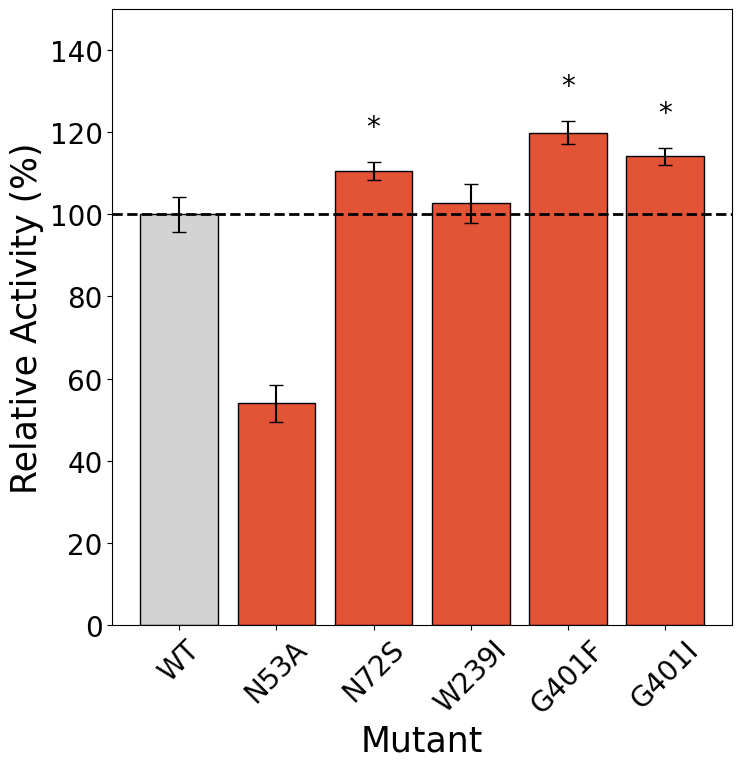

In [11]:
width = 0.8  # the width of the bars
fig, ax = plt.subplots(figsize=(8, 8))
ax.bar(relact_ordered.iloc[0].name, relact_ordered['rel_act_avg'].iloc[0], yerr = relact_ordered['rel_act_std'].iloc[0], capsize=5,
       width=width, color='lightgrey', edgecolor='black')
ax.bar(relact_ordered.iloc[1:].index, relact_ordered['rel_act_avg'].iloc[1:], yerr=relact_ordered['rel_act_std'].iloc[1:], capsize=5,
       width=width, color='#E35336', edgecolor='black')

for i, res in enumerate(results):
    i += 1
    if res['Significant']:
        ax.text(i, relact_ordered['rel_act_avg'].iloc[i] + relact_ordered['rel_act_std'].iloc[i] + 5, '*', 
                ha='center', va='bottom', color='k', fontsize=20)
        
ax.set_ylim(0, 150)
        
ax.axhline(100, color='black', linewidth=2, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xticklabels(relact_ordered.index,fontsize=20,rotation=45)
ax.set_xlabel('Mutant', fontsize=25)
ax.set_ylabel('Relative Activity (%)', fontsize=25)